In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

In [3]:
#Load the dataset
file_path = 'crop_yield.csv'
df = pd.read_csv(file_path)

# Display the first few rows
df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


In [4]:
# Remove missing values
df.dropna(inplace=True)

# Filter dataset for a specific crop (e.g., Rice)
crop = 'Rice'
df_crop = df[df['Crop'] == crop]




In [5]:
# Group data by state and calculate yield
states = df_crop['State'].unique()
groups = [df_crop[df_crop['State'] == state]['Yield'] for state in states]

# Perform ANOVA test
f_stat, p_value = f_oneway(*groups)
print(f'F-statistic: {f_stat}, P-value: {p_value}')

F-statistic: 47.799891734340896, P-value: 1.2023296127317715e-175


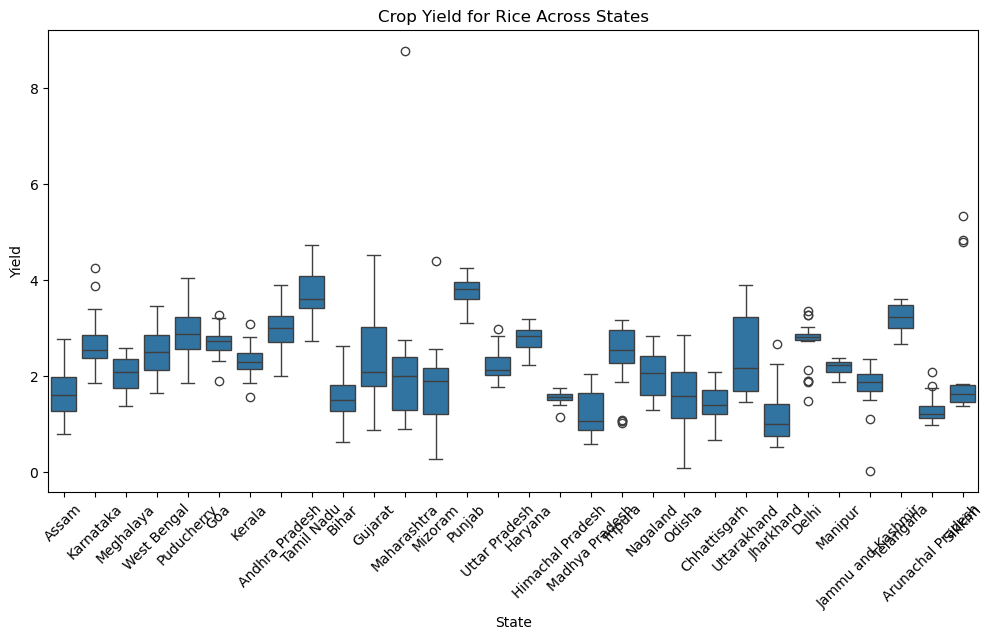

In [6]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='State', y='Yield', data=df_crop)
plt.title(f'Crop Yield for {crop} Across States')
plt.xticks(rotation=45)
plt.show()
